## CarDekho Used Car Price Analysis & Prediction

### Project Overview

In this project, I analyzed used car data to understand what affects car selling prices and built a machine learning model to predict the price.

In [1]:
## Import Libraries & Load Dataset3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [2]:
## Initial Data Understanding
df.head()
df.shape

(4340, 8)

In [3]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df.describe()


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

## Data Cleaning

In [7]:

df.duplicated().sum()

np.int64(763)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(3577, 8)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.sort_values("selling_price", ascending=False).head(10)         #highest selling price

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016,5500000,77350,Diesel,Dealer,Automatic,First Owner
555,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner
3883,BMW 5 Series 520d Luxury Line,2019,4800000,12999,Diesel,Dealer,Automatic,First Owner
3453,BMW 5 Series 520d Luxury Line,2018,4800000,9422,Diesel,Individual,Automatic,First Owner
963,Audi A5 Sportback,2020,4700000,1500,Diesel,Individual,Automatic,First Owner
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,2018,4500000,9800,Petrol,Dealer,Automatic,First Owner
4047,Volvo XC 90 D5 Inscription BSIV,2017,4500000,80000,Diesel,Individual,Automatic,First Owner
539,Mercedes-Benz GL-Class 350 CDI Blue Efficiency,2014,4400000,100000,Diesel,Individual,Automatic,Second Owner


In [12]:
df.sort_values("km_driven", ascending=False).head(10)                 #highest km driven

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1243,Maruti Swift VXI BSIII,2009,250000,806599,Petrol,Dealer,Manual,First Owner
525,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner
3679,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2006,400000,400000,Diesel,Individual,Manual,Third Owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Individual,Manual,Second Owner
2394,Toyota Innova 2.5 V Diesel 8-seater,2009,350000,350000,Diesel,Individual,Manual,First Owner
3718,Toyota Innova 2.5 GX 8 STR BSIV,2009,420000,347089,Diesel,Dealer,Manual,First Owner
1674,Volkswagen Jetta 2.0 TDI Comfortline,2011,350000,312000,Diesel,Individual,Manual,Third Owner
3994,Tata Indica GLS BS IV,2010,75000,300000,Petrol,Individual,Manual,Third Owner
1659,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006,229999,300000,Diesel,Individual,Manual,First Owner
3898,Tata Indica GLS BS IV,2010,90000,300000,Petrol,Individual,Manual,Third Owner


In [13]:
df["year"].value_counts().sort_index()


year
1992      1
1995      1
1996      2
1997      3
1998      9
1999      9
2000     12
2001     16
2002     18
2003     22
2004     38
2005     61
2006     93
2007    117
2008    129
2009    169
2010    210
2011    247
2012    338
2013    298
2014    321
2015    332
2016    283
2017    346
2018    295
2019    162
2020     45
Name: count, dtype: int64

In [14]:
df["fuel"].value_counts()

fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

In [15]:
df["seller_type"].value_counts()

seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64

In [16]:
df["transmission"].value_counts()

transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

In [17]:
df["owner"].value_counts()

owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64

### Remove Test Drive Cars

In [18]:
df[df["owner"] == "Test Drive Car"]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1714,Ford Freestyle Titanium Diesel,2020,784000,101,Diesel,Dealer,Manual,Test Drive Car
1715,Ford Figo Titanium,2020,635000,101,Petrol,Dealer,Manual,Test Drive Car
1716,Ford Ecosport 1.5 Diesel Titanium,2020,1000000,101,Diesel,Dealer,Manual,Test Drive Car
1774,Ford Aspire Titanium BSIV,2020,828999,1010,Petrol,Dealer,Manual,Test Drive Car
1775,Ford EcoSport 1.5 Ti VCT MT Titanium BE BSIV,2020,1119000,1010,Petrol,Dealer,Manual,Test Drive Car
1776,Ford Figo Titanium,2020,746000,1111,Petrol,Dealer,Manual,Test Drive Car
1777,Ford Ecosport 1.5 Petrol Trend,2020,1030000,1010,Petrol,Dealer,Manual,Test Drive Car
1778,Ford EcoSport 1.5 TDCi Titanium Plus BSIV,2020,1334000,1010,Diesel,Dealer,Manual,Test Drive Car
1779,Ford Freestyle Titanium,2020,811999,1010,Petrol,Dealer,Manual,Test Drive Car
1780,Ford Ecosport Thunder Edition Diesel,2020,1331000,1010,Diesel,Dealer,Manual,Test Drive Car


In [19]:
df[df["owner"] == "Test Drive Car"]["selling_price"].describe()

count    1.700000e+01
mean     9.542939e+05
std      2.503725e+05
min      5.410000e+05
25%      7.840000e+05
50%      8.949990e+05
75%      1.119000e+06
max      1.350000e+06
Name: selling_price, dtype: float64

In [20]:
df = df[df["owner"] != "Test Drive Car"]

In [21]:
df.shape

(3560, 8)

In [22]:
df["owner"].value_counts()

owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Name: count, dtype: int64

## Car Age Analysis

In [23]:

analysis_year = 2026
df["car_age"] = analysis_year - df["year"]

In [24]:
df[["year", "car_age"]].head(10)

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12
5,2007,19
6,2016,10
7,2014,12
8,2015,11
9,2017,9


In [25]:
df["car_age"].describe()

count    3560.000000
mean       13.068820
std         4.237145
min         6.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        34.000000
Name: car_age, dtype: float64

In [26]:
df[df["car_age"] < 0]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age


In [27]:
#Does an older car generally sell for a lower price?
age_price = df.groupby("car_age")["selling_price"].mean().reset_index()

age_price

,car_age,selling_price
0,6,763787.878788
1,7,860654.062893
2,8,819248.265306
3,9,741304.304348
4,10,638342.706714
5,11,510051.159639
6,12,512850.420561
7,13,433046.285235
8,14,379352.026627
9,15,296028.291498


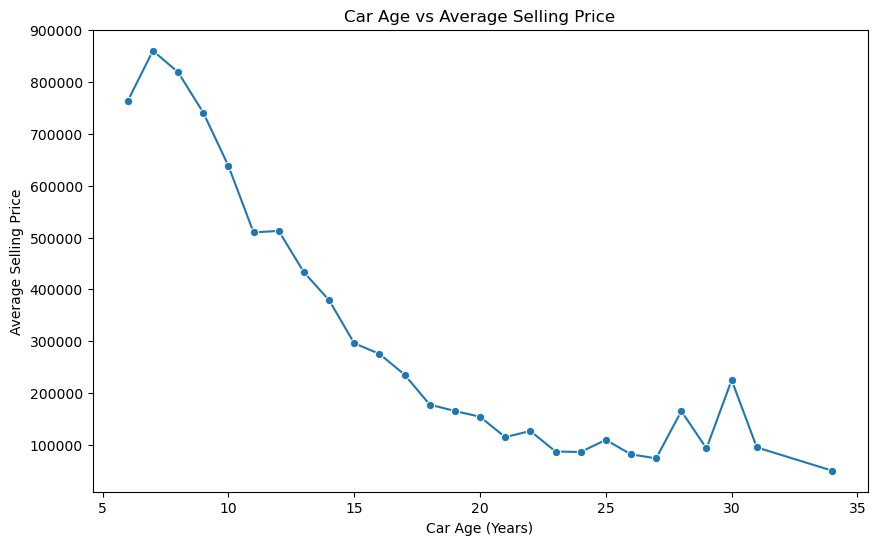

In [28]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_price,
    x="car_age",
    y="selling_price",
    marker="o"
)

plt.title("Car Age vs Average Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Average Selling Price")

plt.show()

In [29]:
df[["car_age", "selling_price"]].corr()

,car_age,selling_price
car_age,1.000000,-0.420881
selling_price,-0.420881,1.000000


## Mileage Analysis

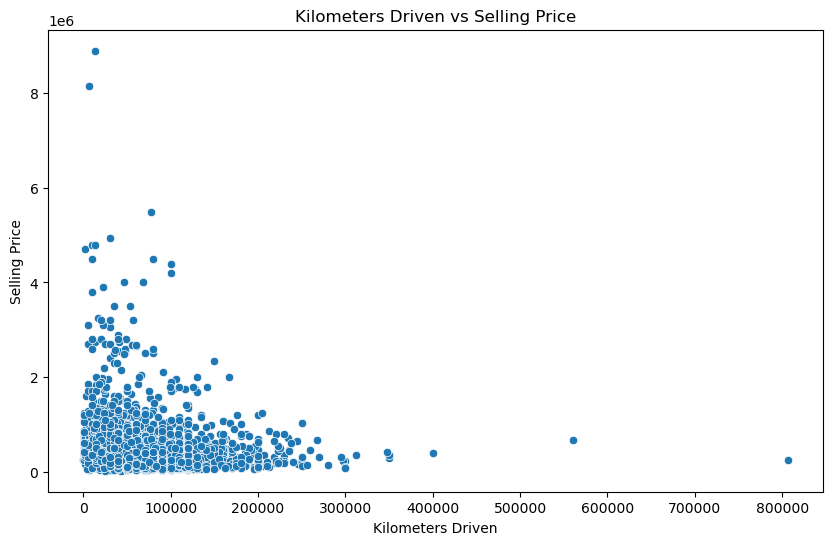

In [30]:
df[["km_driven", "selling_price"]].corr()
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

In [31]:
df[["km_driven", "selling_price"]].corr()


,km_driven,selling_price
km_driven,1.000000,-0.182489
selling_price,-0.182489,1.000000


## Fuel Analysis

In [32]:
df.groupby("fuel")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
fuel,,,
Diesel,1793,612274.364752,475000.0
Petrol,1707,332136.633861,260000.0
Electric,1,310000.000000,310000.0
CNG,37,273162.081081,229999.0
LPG,22,171818.136364,180000.0


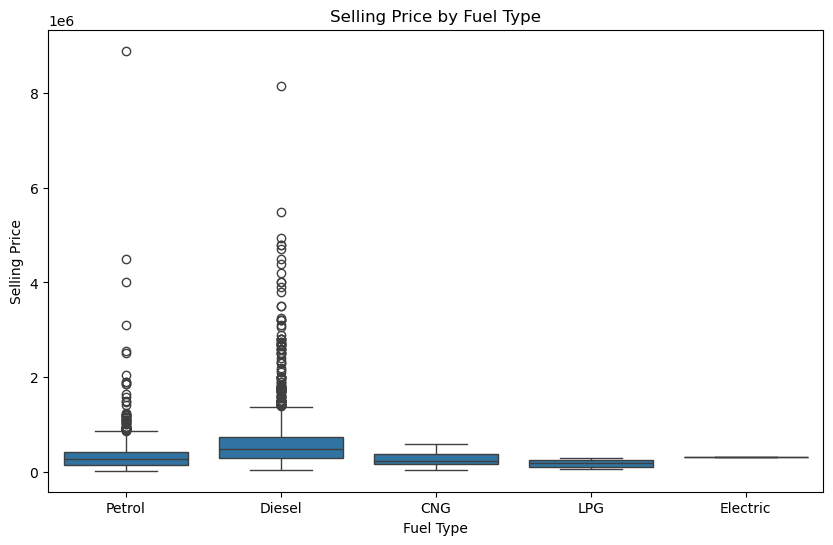

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

In [34]:
df.groupby("fuel")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
fuel,,,
Diesel,1793,612274.364752,475000.0
Petrol,1707,332136.633861,260000.0
Electric,1,310000.000000,310000.0
CNG,37,273162.081081,229999.0
LPG,22,171818.136364,180000.0


## Transmission Analysis

In [35]:
df.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
transmission,,,
Automatic,311,1.275309e+06,850000.0
Manual,3249,3.946880e+05,320000.0


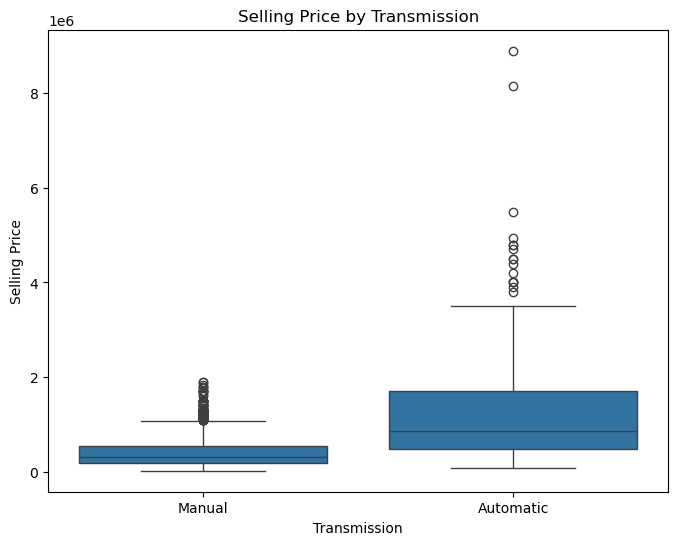

In [36]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

In [37]:
#"Automatic vehicles have substantially higher selling prices than manual vehicles in this dataset,
#although this difference may also reflect differences in vehicle model, age, and other characteristics."

In [38]:
df.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
transmission,,,
Automatic,311,1.275309e+06,850000.0
Manual,3249,3.946880e+05,320000.0


## Owner Analysis

In [39]:
df.groupby("owner")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
owner,,,
First Owner,2218,565385.447250,450000.0
Second Owner,978,341954.140082,267000.0
Third Owner,289,266142.207612,190000.0
Fourth & Above Owner,75,181213.293333,138000.0


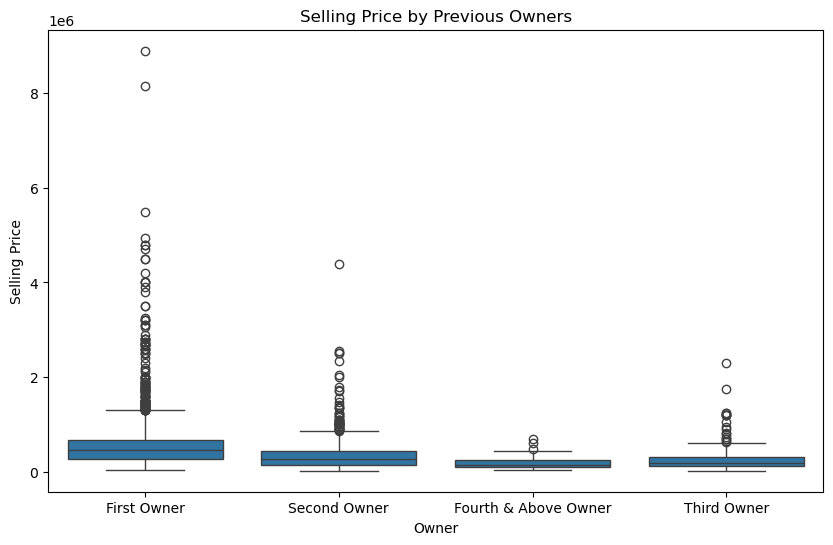

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="owner",
    y="selling_price"
)

plt.title("Selling Price by Previous Owners")
plt.xlabel("Owner")
plt.ylabel("Selling Price")

plt.show()

In [41]:
df.groupby("owner")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)


,count,mean,median
owner,,,
First Owner,2218,565385.447250,450000.0
Second Owner,978,341954.140082,267000.0
Third Owner,289,266142.207612,190000.0
Fourth & Above Owner,75,181213.293333,138000.0


## Seller Type Analysis

In [42]:
df.groupby("seller_type")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
seller_type,,,
Trustmark Dealer,33,822272.727273,750000.0
Dealer,695,645322.257554,475000.0
Individual,2832,424904.024364,303500.0


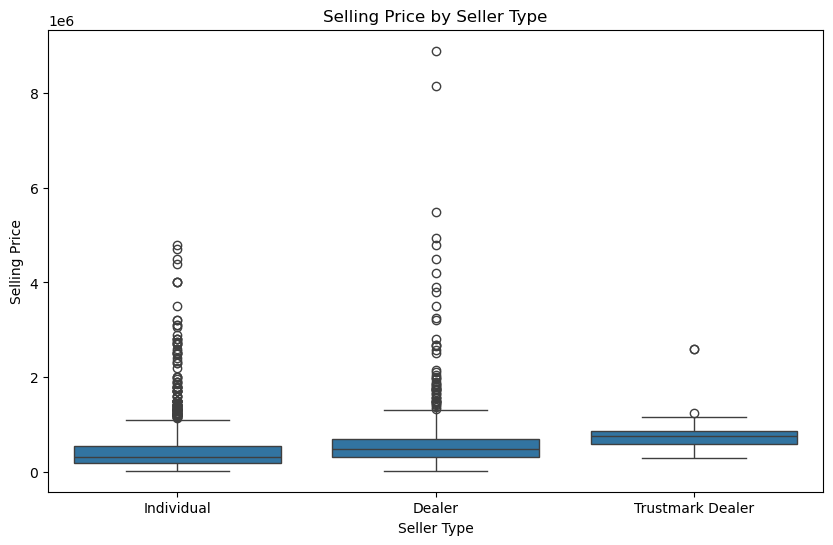

In [43]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")

plt.show()

In [44]:
df.groupby("seller_type")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
seller_type,,,
Trustmark Dealer,33,822272.727273,750000.0
Dealer,695,645322.257554,475000.0
Individual,2832,424904.024364,303500.0


## Correlation Analysis

In [45]:
numeric_cols = [
    "year",
    "selling_price",
    "km_driven",
    "car_age"
]

corr = df[numeric_cols].corr()

corr

,year,selling_price,km_driven,car_age
year,1.000000,0.420881,-0.411513,-1.000000
selling_price,0.420881,1.000000,-0.182489,-0.420881
km_driven,-0.411513,-0.182489,1.000000,0.411513
car_age,-1.000000,-0.420881,0.411513,1.000000


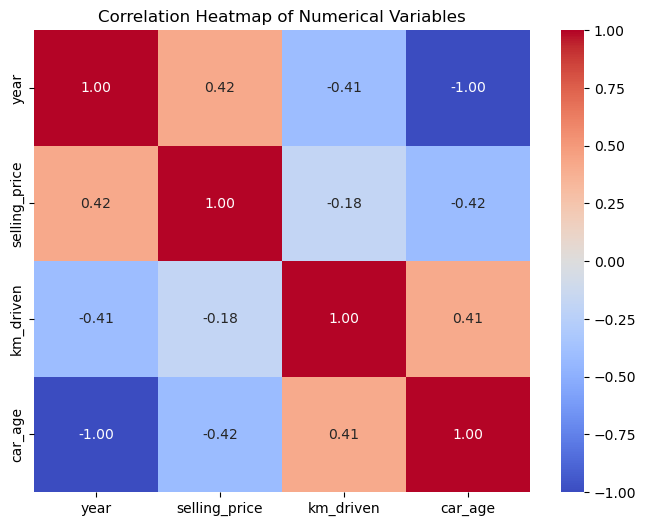

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

## Machine Learning


In [47]:
#preparing for machine learning model
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 3560 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3560 non-null   object
 1   year           3560 non-null   int64 
 2   selling_price  3560 non-null   int64 
 3   km_driven      3560 non-null   int64 
 4   fuel           3560 non-null   object
 5   seller_type    3560 non-null   object
 6   transmission   3560 non-null   object
 7   owner          3560 non-null   object
 8   car_age        3560 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 278.1+ KB


(3560, 9)

In [48]:
X = df[
    [
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ]
]

y = df["selling_price"]

In [49]:
X.head()


,car_age,km_driven,fuel,seller_type,transmission,owner
0,19,70000,Petrol,Individual,Manual,First Owner
1,19,50000,Petrol,Individual,Manual,First Owner
2,14,100000,Diesel,Individual,Manual,First Owner
3,9,46000,Petrol,Individual,Manual,First Owner
4,12,141000,Diesel,Individual,Manual,Second Owner


In [50]:
y.head()

0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64

In [51]:
X.shape, y.shape

((3560, 6), (3560,))

In [52]:
X_encoded = pd.get_dummies(
    X,
    columns=["fuel", "seller_type", "transmission", "owner"],
    drop_first=True
)

In [53]:
X_encoded.head()

,car_age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,19,70000,False,False,False,True,True,False,True,False,False,False
1,19,50000,False,False,False,True,True,False,True,False,False,False
2,14,100000,True,False,False,False,True,False,True,False,False,False
3,9,46000,False,False,False,True,True,False,True,False,False,False
4,12,141000,True,False,False,False,True,False,True,False,True,False


In [54]:
X_encoded.shape

(3560, 12)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [56]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2848, 12), (712, 12), (2848,), (712,))

### Linear Regression

In [57]:
#Linear regression model
from sklearn.linear_model import LinearRegression

In [58]:
lr_model = LinearRegression()

In [59]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred_lr = lr_model.predict(X_test)

In [61]:
y_pred_lr[:10]

array([370358.87546258, 232953.25251044, 490122.59785374, 174971.76625233,
       527450.68272424, 185392.51258241,  50341.46590836,  72663.63156088,
         3973.41557412, 190892.8180621 ])

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 205873.14127101013
RMSE: 426978.0617376851
R²  : 0.3992741589409904


### Random Forest

In [63]:

from sklearn.ensemble import RandomForestRegressor

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

In [65]:
rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf = rf_model.predict(X_test)

In [67]:
y_pred_rf[:10]

array([268996.41903265, 327708.26888889, 354053.33333333, 155532.18666667,
       239769.98666667, 189375.02908598, 121973.32972583, 102006.82539683,
       104536.81484848, 231988.59644444])

In [68]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 197630.217300845
RMSE: 424806.5467853987
R²  : 0.40536893571195654


In [69]:
# Random Forest performed slightly better than Linear Regression, but the improvement was modest.

In [70]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

importance

km_driven                       0.279727
car_age                         0.275456
transmission_Manual             0.253218
fuel_Diesel                     0.077070
fuel_Petrol                     0.042458
seller_type_Individual          0.040404
owner_Second Owner              0.022524
owner_Third Owner               0.004602
seller_type_Trustmark Dealer    0.003547
owner_Fourth & Above Owner      0.000953
fuel_LPG                        0.000041
fuel_Electric                   0.000000
dtype: float64

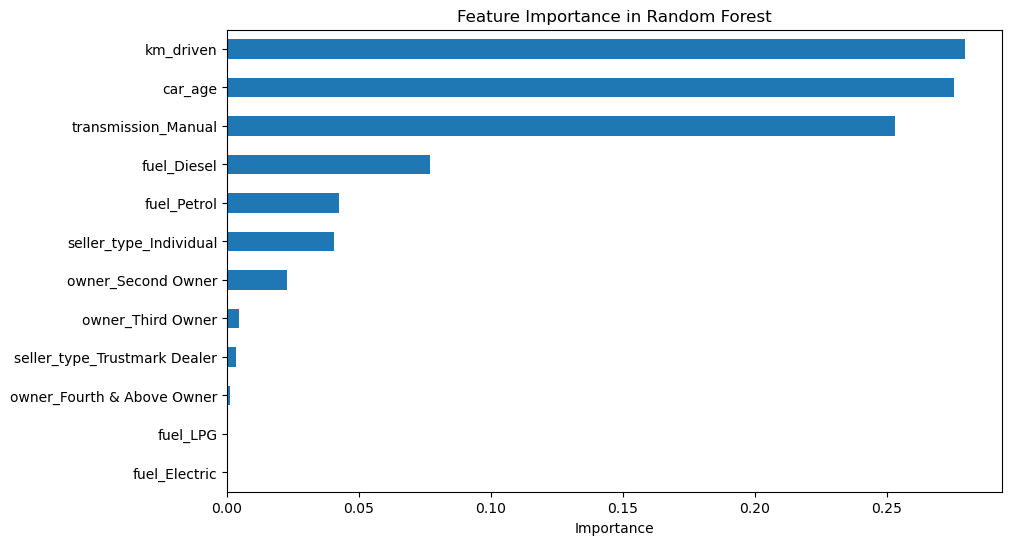

In [71]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance")

plt.show()

In [72]:
df["name"].head(20).tolist()

['Maruti 800 AC',
 'Maruti Wagon R LXI Minor',
 'Hyundai Verna 1.6 SX',
 'Datsun RediGO T Option',
 'Honda Amaze VX i-DTEC',
 'Maruti Alto LX BSIII',
 'Hyundai Xcent 1.2 Kappa S',
 'Tata Indigo Grand Petrol',
 'Hyundai Creta 1.6 VTVT S',
 'Maruti Celerio Green VXI',
 'Chevrolet Sail 1.2 Base',
 'Tata Indigo Grand Petrol',
 'Toyota Corolla Altis 1.8 VL CVT',
 'Maruti Ciaz VXi Plus',
 'Hyundai Venue SX Opt Diesel',
 'Chevrolet Enjoy TCDi LTZ 7 Seater',
 'Jaguar XF 2.2 Litre Luxury',
 'Mercedes-Benz New C-Class 220 CDI AT',
 'Maruti Vitara Brezza ZDi Plus AMT',
 'Audi Q5 2.0 TDI']

## Adding Brand Feature

In [73]:
df["brand"] = df["name"].str.split().str[0]

In [74]:
df[["name", "brand"]].head(20)

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Hyundai Xcent 1.2 Kappa S,Hyundai
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


In [75]:
df["brand"].value_counts()

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Honda             214
Ford              207
Toyota            170
Chevrolet         151
Renault           109
Volkswagen         92
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [76]:
brand_analysis = df.groupby("brand")["selling_price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

brand_analysis

,count,mean,median
brand,,,
Land,5,3.609800e+06,4000000.0
Volvo,4,2.556250e+06,1987500.0
Mercedes-Benz,21,2.299238e+06,1451000.0
BMW,25,2.242800e+06,2150000.0
Audi,31,2.185452e+06,1580000.0
Jaguar,5,2.073000e+06,2000000.0
MG,2,1.842500e+06,1842500.0
Jeep,3,1.530000e+06,1490000.0
Isuzu,1,1.500000e+06,1500000.0


In [77]:
brand_analysis[brand_analysis["count"] >= 20]

,count,mean,median
brand,,,
Mercedes-Benz,21,2.299238e+06,1451000.0
BMW,25,2.242800e+06,2150000.0
Audi,31,2.185452e+06,1580000.0
Toyota,170,8.389176e+05,650000.0
Mahindra,328,5.847804e+05,532500.0
Ford,207,5.387971e+05,459999.0
Honda,214,5.362757e+05,492500.0
Skoda,49,4.755510e+05,400000.0
Nissan,52,4.570384e+05,437499.5


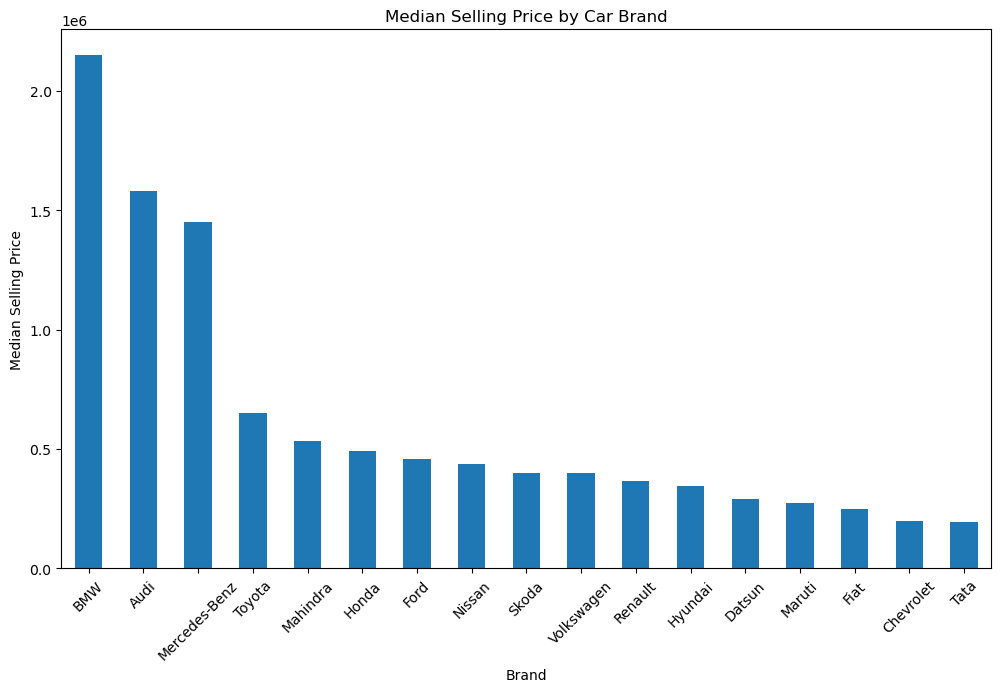

In [78]:
top_brands = (
    df["brand"]
    .value_counts()
    .loc[lambda x: x >= 20]
    .index
)

brand_plot = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["selling_price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

brand_plot.plot(kind="bar")

plt.title("Median Selling Price by Car Brand")
plt.xlabel("Brand")
plt.ylabel("Median Selling Price")

plt.xticks(rotation=45)

plt.show()

In [79]:
df[df["brand"] == "Land"]["name"].tolist()

['Land Rover Discovery Sport TD4 HSE 7S',
 'Land Rover Discovery S 2.0 SD4',
 'Land Rover Discovery Sport SD4 HSE Luxury',
 'Land Rover Range Rover Evoque 2.2L Dynamic',
 'Land Rover Range Rover 4.4 Diesel LWB Vogue SE']

In [80]:
df.loc[df["brand"] == "Land", "brand"] = "Land Rover"

In [81]:
df["brand"].value_counts()

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Honda             214
Ford              207
Toyota            170
Chevrolet         151
Renault           109
Volkswagen         92
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land Rover          5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [82]:
df[df["brand"] == "Land Rover"][["name", "brand"]]

,name,brand
731,Land Rover Discovery Sport TD4 HSE 7S,Land Rover
988,Land Rover Discovery S 2.0 SD4,Land Rover
1088,Land Rover Discovery Sport SD4 HSE Luxury,Land Rover
3596,Land Rover Range Rover Evoque 2.2L Dynamic,Land Rover
3875,Land Rover Range Rover 4.4 Diesel LWB Vogue SE,Land Rover


### Random Forest with Brand

In [83]:
X_brand = df[
    [
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner",
        "brand"
    ]
]

In [84]:
X_brand_encoded = pd.get_dummies(
    X_brand,
    columns=[
        "fuel",
        "seller_type",
        "transmission",
        "owner",
        "brand"
    ],
    drop_first=True
)

In [85]:
X_brand_encoded.shape

(3560, 40)

In [86]:
X_train_brand, X_test_brand, y_train_brand, y_test_brand = train_test_split(
    X_brand_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [87]:
X_train_brand.shape, X_test_brand.shape

((2848, 40), (712, 40))

In [88]:
rf_brand = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_brand.fit(X_train_brand, y_train_brand)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
y_pred_rf_brand = rf_brand.predict(X_test_brand)

In [90]:
y_pred_rf_brand[:10]

array([277442.78073112, 309045.57333333, 248696.66666667, 144076.65333333,
       453943.03222222, 208692.18253968, 140699.83793651,  98446.66666667,
       109869.46428571, 234777.59007937])

In [91]:
mae_rf_brand = mean_absolute_error(y_test_brand, y_pred_rf_brand)

rmse_rf_brand = np.sqrt(
    mean_squared_error(y_test_brand, y_pred_rf_brand)
)

r2_rf_brand = r2_score(y_test_brand, y_pred_rf_brand)

print("Random Forest + Brand Results")
print("----------------------------")
print("MAE :", mae_rf_brand)
print("RMSE:", rmse_rf_brand)
print("R²  :", r2_rf_brand)

Random Forest + Brand Results
----------------------------
MAE : 152581.47420912993
RMSE: 334852.9460122004
R²  : 0.6305348839781887


In [92]:
# Adding car brand substantially improved Random Forest performance, increasing R² from 0.405 to 0.631 and reducing MAE from approximately ₹1.98 lakh to ₹1.53 lakh.
# This indicates that brand is an important predictor of used-car selling price.

In [93]:
brand_importance = pd.Series(
    rf_brand.feature_importances_,
    index=X_brand_encoded.columns
).sort_values(ascending=False)

brand_importance.head(15)

transmission_Manual       0.243162
car_age                   0.227048
km_driven                 0.140242
fuel_Diesel               0.074018
brand_Audi                0.056081
fuel_Petrol               0.040755
brand_Toyota              0.035760
brand_Land Rover          0.021164
seller_type_Individual    0.019220
brand_Mercedes-Benz       0.017994
brand_BMW                 0.017384
brand_Maruti              0.010248
brand_Jaguar              0.009722
owner_Second Owner        0.009433
brand_Mahindra            0.008696
dtype: float64

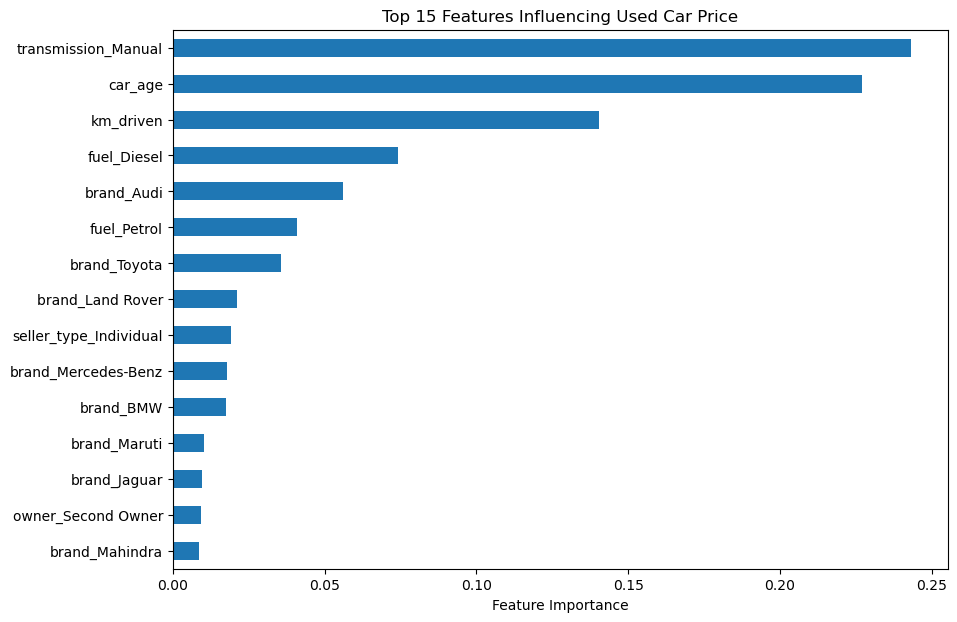

In [94]:
plt.figure(figsize=(10, 7))

brand_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Features Influencing Used Car Price")
plt.xlabel("Feature Importance")

plt.show()

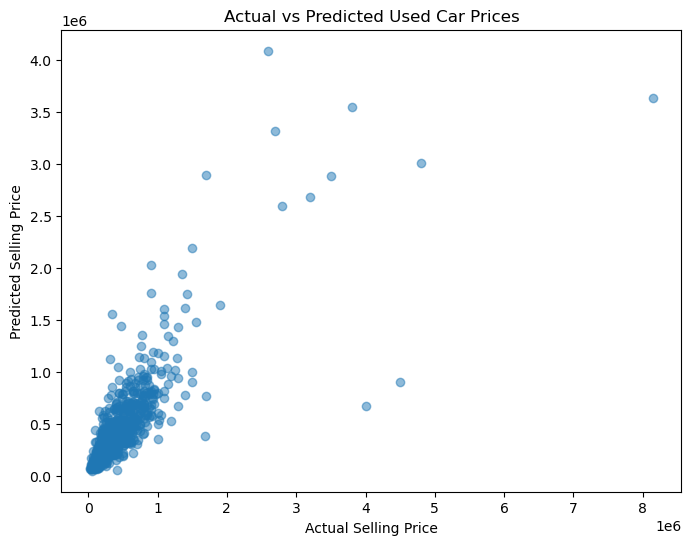

In [95]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_brand, y_pred_rf_brand, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Used Car Prices")

plt.show()

## Adding Car Model Feature

In [96]:
df["model"] = df["name"].str.split().str[1]

df[["name", "brand", "model"]].head(10)

,name,brand,model
0,Maruti 800 AC,Maruti,800
1,Maruti Wagon R LXI Minor,Maruti,Wagon
2,Hyundai Verna 1.6 SX,Hyundai,Verna
3,Datsun RediGO T Option,Datsun,RediGO
4,Honda Amaze VX i-DTEC,Honda,Amaze
5,Maruti Alto LX BSIII,Maruti,Alto
6,Hyundai Xcent 1.2 Kappa S,Hyundai,Xcent
7,Tata Indigo Grand Petrol,Tata,Indigo
8,Hyundai Creta 1.6 VTVT S,Hyundai,Creta
9,Maruti Celerio Green VXI,Maruti,Celerio


In [97]:
df["model"].nunique()

185

In [98]:
df["model"].value_counts().head(20)

model
Swift      270
Alto       228
Wagon      139
i20        113
Verna      103
Innova      89
Indica      86
Scorpio     85
Santro      84
City        79
Grand       77
EON         77
Figo        77
XUV500      64
i10         60
Bolero      59
Beat        56
KWID        54
Ertiga      51
Zen         51
Name: count, dtype: int64

In [99]:
df["model"].value_counts().describe()

count    185.000000
mean      19.243243
std       34.006717
min        1.000000
25%        2.000000
50%        8.000000
75%       20.000000
max      270.000000
Name: count, dtype: float64

In [100]:
(df["model"].value_counts() >= 10).sum()

np.int64(80)

In [101]:
model_counts = df["model"].value_counts()

df["model_group"] = df["model"].where(
    df["model"].isin(model_counts[model_counts >= 10].index),
    "Other"
)

In [102]:
df["model_group"].nunique()

81

In [103]:
df["model_group"].value_counts().head(20)

model_group
Other      342
Swift      270
Alto       228
Wagon      139
i20        113
Verna      103
Innova      89
Indica      86
Scorpio     85
Santro      84
City        79
Figo        77
Grand       77
EON         77
XUV500      64
i10         60
Bolero      59
Beat        56
KWID        54
Ertiga      51
Name: count, dtype: int64

## Final Model: Brand + Model

In [104]:
X_model = df[
    ["car_age", "km_driven", "fuel", "seller_type",
     "transmission", "owner", "brand", "model_group"]
]

y_model = df["selling_price"]

In [105]:
X_model_encoded = pd.get_dummies(
    X_model,
    columns=[
        "fuel",
        "seller_type",
        "transmission",
        "owner",
        "brand",
        "model_group"
    ],
    drop_first=True
)

X_model_encoded.shape

(3560, 120)

In [106]:
X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(
    X_model_encoded,
    y_model,
    test_size=0.20,
    random_state=42
)

X_train_model.shape, X_test_model.shape

((2848, 120), (712, 120))

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_model = mean_absolute_error(y_test_model, y_pred_model)
rmse_model = np.sqrt(mean_squared_error(y_test_model, y_pred_model))
r2_model = r2_score(y_test_model, y_pred_model)

print("MAE:", mae_model)
print("RMSE:", rmse_model)
print("R²:", r2_model)

NameError: name 'y_pred_model' is not defined

In [ ]:
# Including the specific car model substantially improved price prediction. 
# This indicates that model-level information is much more informative than brand alone when estimating used-car prices.

## Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest + Brand",
        "Random Forest + Brand + Model"
    ],
    "MAE": [
        205873,
        197630.2173,
        152581.4742,
        mae_model
    ],
    "RMSE": [
        426978,
        424806.5468,
        334852.9460,
        rmse_model
    ],
    "R2": [
        0.3993,
        0.4054,
        0.6305,
        r2_model
    ]
})

model_comparison

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [ ]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_model, y_train_model)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV R²:")
print(random_search.best_score_)

In [ ]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_model)

In [ ]:
mae_tuned = mean_absolute_error(y_test_model, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_model, y_pred_tuned))
r2_tuned = r2_score(y_test_model, y_pred_tuned)

print("Tuned Model MAE:", mae_tuned)
print("Tuned Model RMSE:", rmse_tuned)
print("Tuned Model R²:", r2_tuned)

In [ ]:
brand_price = (
    df.groupby("brand")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

brand_price.head(10)

## Business Insights

In [ ]:


# Premium and luxury brands generally show higher used-car selling prices in this dataset. 
# However, brands with very small sample sizes should be interpreted cautiously.

In [ ]:
model_price = (
    df.groupby("model_group")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
 
model_price.head(10)

In [ ]:
# SUV models such as Fortuner, Endeavour, Creta, and XUV500 command relatively higher used-car prices in this dataset. 
# Model-level differences are therefore important for accurate resale-price estimation.

In [ ]:
age_price = (
    df.groupby("car_age")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_index()
)

age_price.head(10)

In [ ]:
km_price = (
    df.groupby(pd.cut(df["km_driven"], bins=5))["selling_price"]
    .agg(["count", "mean", "median"])
)

km_price

In [ ]:
km_price = (
    df.groupby(
        pd.qcut(df["km_driven"], q=5, duplicates="drop")
    )["selling_price"]
    .agg(["count", "mean", "median"])
)

km_price

## Conclusion

Cars with lower mileage generally have higher resale prices. 
As kilometers driven increase, the average and median selling prices generally decrease.

Brand → Premium brands generally have higher prices.

Model → Specific models have a strong influence on resale price.

Age → Older cars generally have lower resale prices.

Mileage → Higher mileage generally corresponds to lower prices.

ML → Brand + Model dramatically improved prediction performance

The analysis shows that used-car resale prices are influenced by multiple factors, with car model, brand, transmission, vehicle age, and mileage playing important roles. Random Forest performed better than Linear Regression, and adding brand and  specific model information significantly improved prediction performance.The final Random Forest model achieved an R² of 0.818, demonstrating strong predictive performance for estimating used-car selling prices.